# Week 5 Part 2: Data Visualization & Multicollinearity

**Instructor:** Dr. Mahmoud Eid (m.eid@fci-cu.edu.eg)
**Time:** ~1.5 hours

<div dir="rtl">
<b>النهاردة هنتعلم ازاي نستكشف الـ data ونكتشف المشاكل قبل الـ training بإذن الله!</b>
</div>

## Topics

1. Data Visualization Fundamentals
2. Correlation Analysis
3. Multicollinearity Detection (VIF)
4. One method for handling Multicollinearity

**Real Dataset:** California Housing (20,640 houses)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

plt.style.use('dark_background')
np.random.seed(42)
print("✅ Ready!")

✅ Ready!


---

# 1. Data Visualization Fundamentals

**Why Visualize?**

- Understand data distribution
- Detect outliers
- Identify relationships between features
- Make informed preprocessing decisions


In [ ]:
# Load California Housing dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['Price'] = housing.target

print(f"Dataset: California Housing")
print(f"Samples: {len(df_housing):,}")
print(f"Features: {housing.feature_names}")
print(f"\nPreview:")
df_housing.head()

Dataset: California Housing
Samples: 20,640
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Statistical summary
print("Statistical Summary:")
df_housing.describe()

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Distribution Analysis


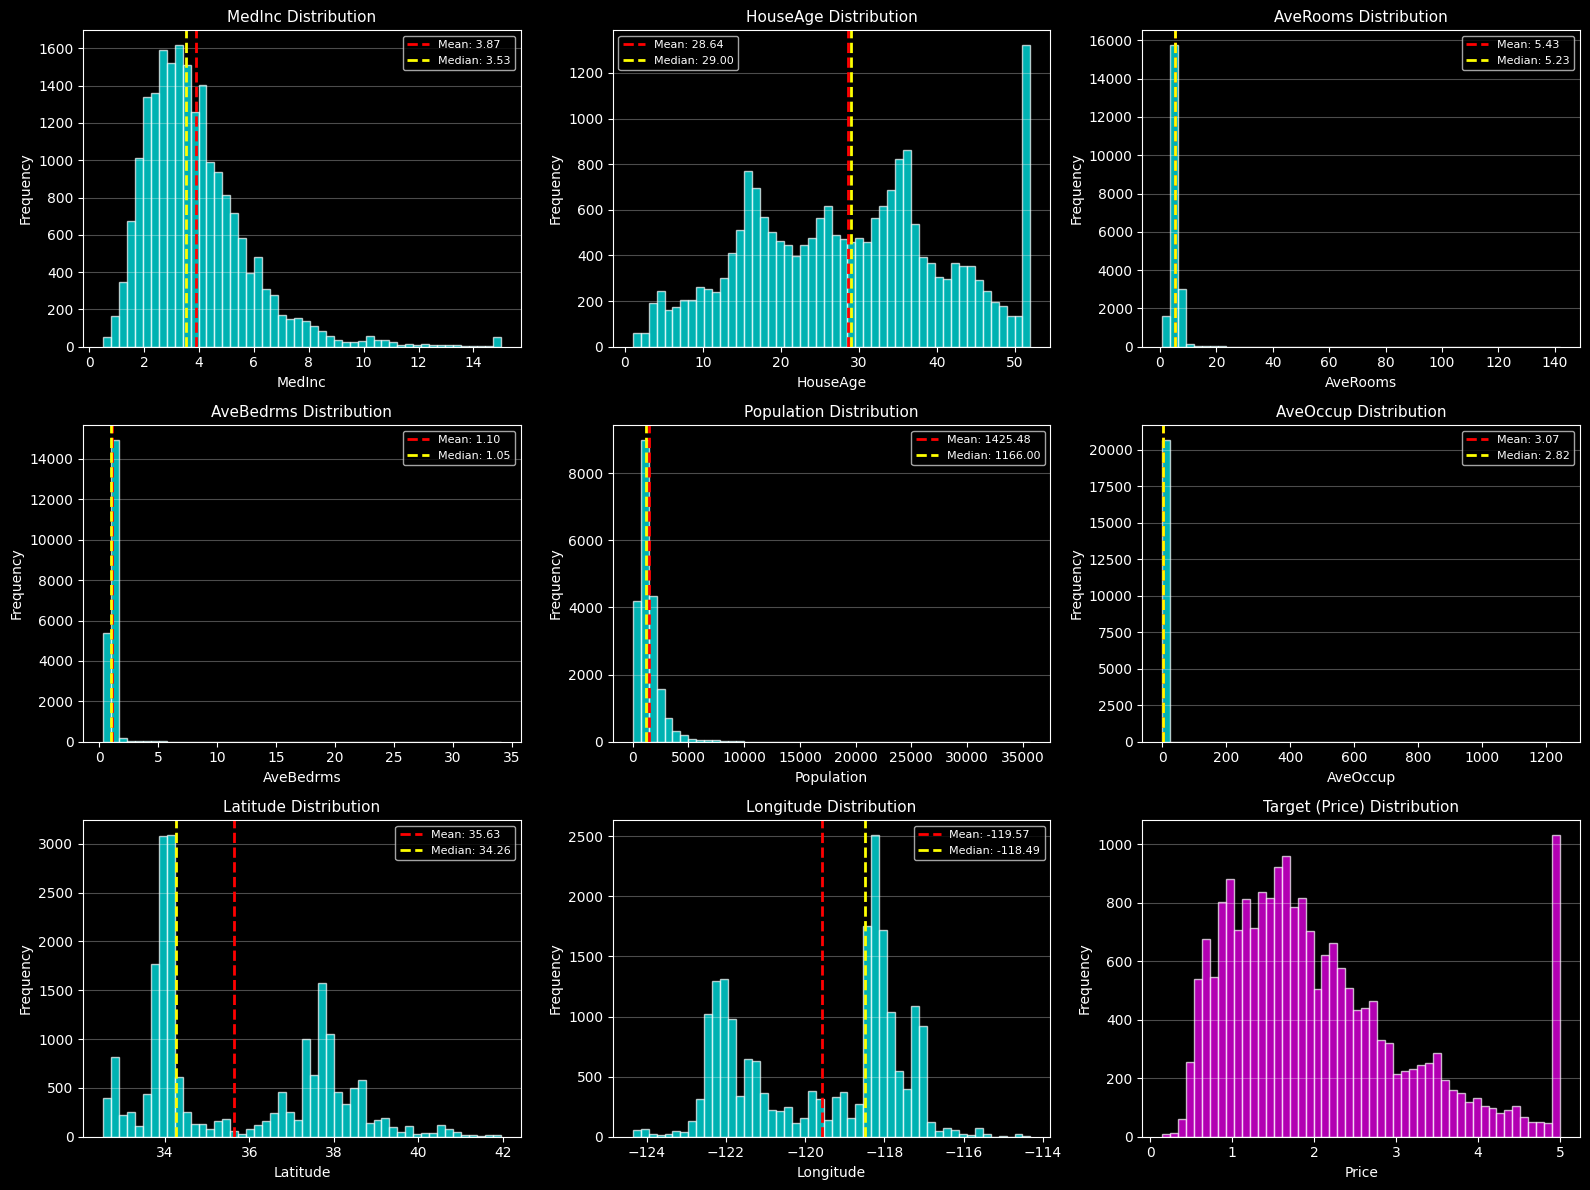

In [ ]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(housing.feature_names):
    axes[i].hist(df_housing[col], bins=50, alpha=0.7, color='cyan', edgecolor='white')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Add mean and median lines
    mean_val = df_housing[col].mean()
    median_val = df_housing[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='yellow', linestyle='--', linewidth=2,
                    label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

# Target distribution
axes[8].hist(df_housing['Price'], bins=50, alpha=0.7, color='magenta', edgecolor='white')
axes[8].set_xlabel('Price', fontsize=10)
axes[8].set_ylabel('Frequency', fontsize=10)
axes[8].set_title('Target (Price) Distribution', fontsize=11)
axes[8].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Box Plots for Outlier Detection

Box plots show:

- **Box:** 25th to 75th percentile (IQR)
- **Line:** Median
- **Whiskers:** 1.5 × IQR
- **Points:** Outliers


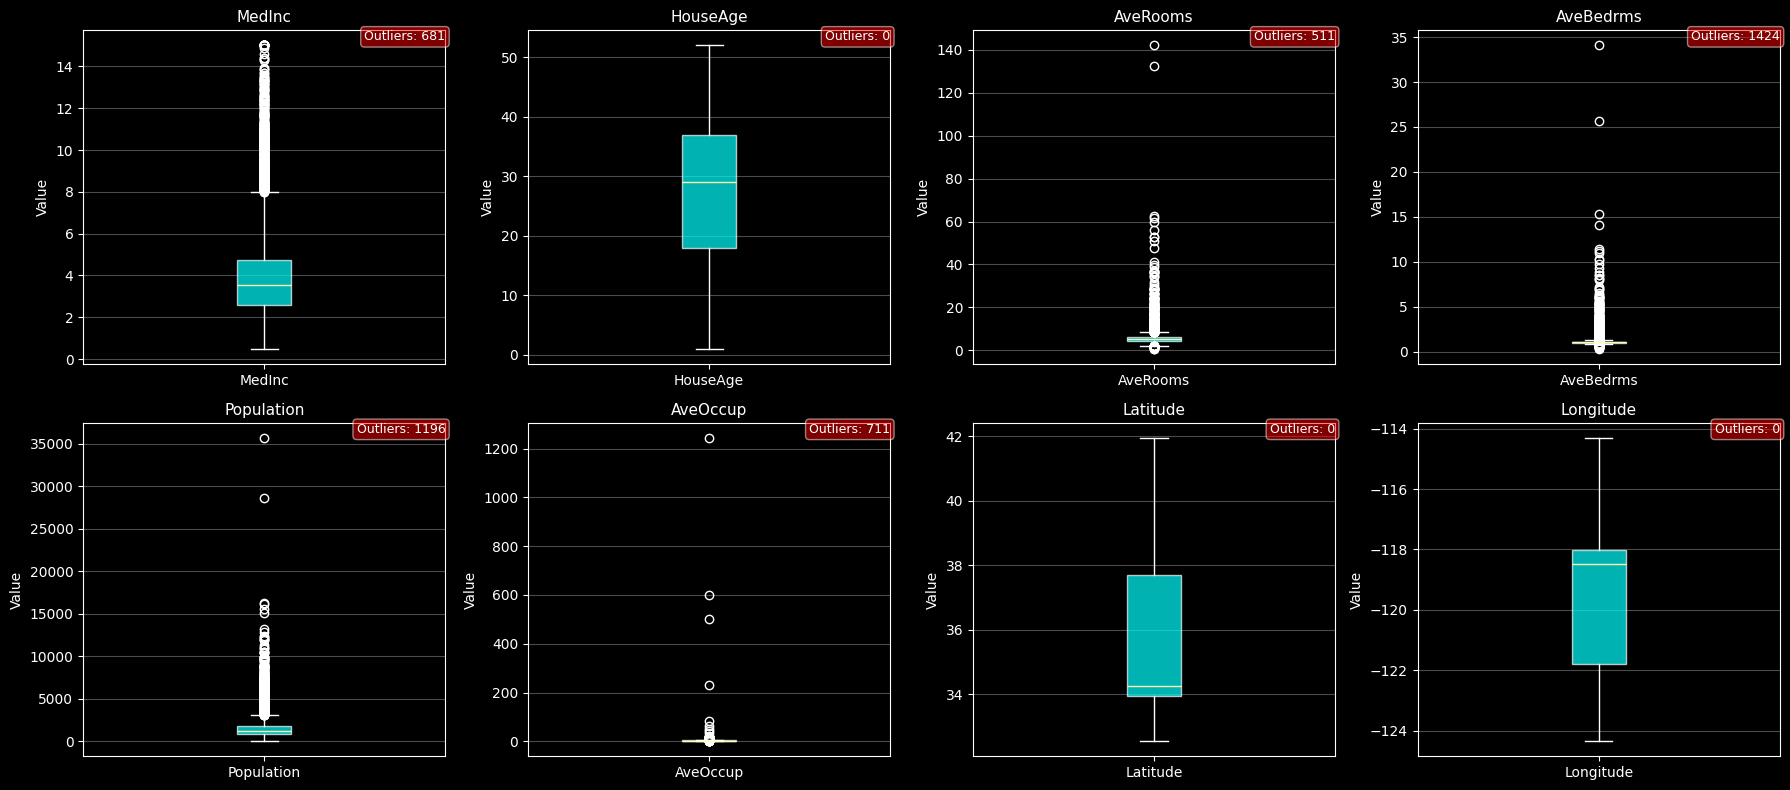

In [ ]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(housing.feature_names):
    bp = axes[i].boxplot([df_housing[col]], tick_labels=[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('cyan')
        patch.set_alpha(0.7)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Count outliers
    Q1 = df_housing[col].quantile(0.25)
    Q3 = df_housing[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_housing[col] < Q1 - 1.5*IQR) | (df_housing[col] > Q3 + 1.5*IQR)).sum()
    axes[i].text(1, 1, f'Outliers: {outliers}', # (0.5, 0.95) = horizontal center, (1, 1) = top-right, (0, 0) = bottom-left
                 transform=axes[i].transAxes, ha='right', va='top',  # Horizontal alignment: 'left', 'center', 'right', # Vertical alignment: 'top', 'center', 'bottom'
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

### Scatter Plot Matrix (Pair Plot)

Shows relationships between all feature pairs.


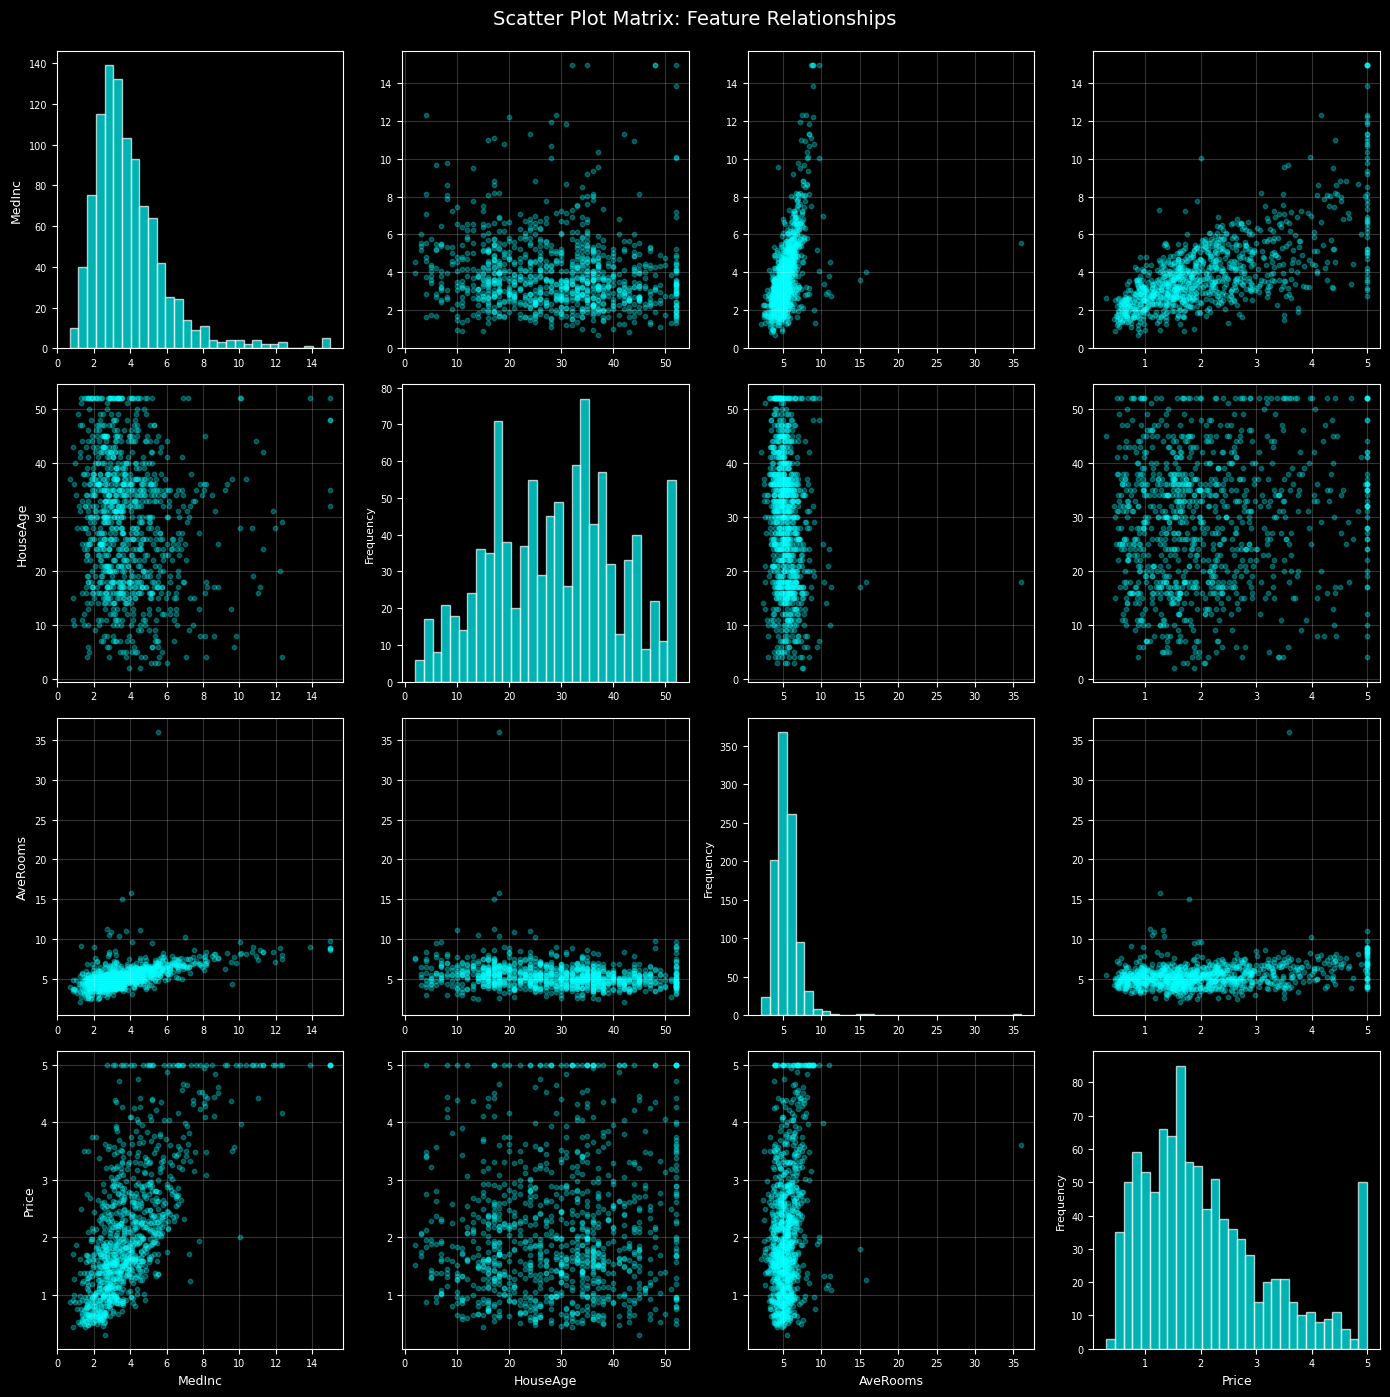

In [ ]:
# Scatter plot matrix (subset of features for clarity)
features_subset = ['MedInc', 'HouseAge', 'AveRooms', 'Price']
df_subset = df_housing[features_subset].sample(1000, random_state=42)

fig = plt.figure(figsize=(14, 14))
n_features = len(features_subset)

for i in range(n_features):
    for j in range(n_features):
        ax = plt.subplot(n_features, n_features, i * n_features + j + 1)

        if i == j:
            # Diagonal: notice that correlation would be highest because this is the feature with itself so instead we put histograms here
            # see how this figure captures many things at once
            ax.hist(df_subset.iloc[:, i], bins=30, color='cyan', alpha=0.7, edgecolor='white')  # Why not scatter? Scatter of a feature against itself would just be a diagonal line (useless!)
            ax.set_ylabel('Frequency', fontsize=8)
        else:
            # Off-diagonal: scatter plots
            ax.scatter(df_subset.iloc[:, j], df_subset.iloc[:, i],
                       alpha=0.3, s=10, color='cyan')
            ax.grid(alpha=0.2)

        # Labels
        if i == n_features - 1:
            ax.set_xlabel(features_subset[j], fontsize=9)
        if j == 0:
            ax.set_ylabel(features_subset[i], fontsize=9)

        ax.tick_params(labelsize=7) #  Sets the font size of tick labels (numbers on axes) to 7 points

plt.suptitle('Scatter Plot Matrix: Feature Relationships', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()



### 🎯 Main Benefits of This Visualization

#### **1. Identifies Strong Predictors**
**MedInc vs Price (bottom-left and top-right corners)**: Shows a **clear positive linear relationship** 📈
  - This is the **strongest relationship** in the entire matrix
  - Higher median income areas → Higher house prices
  - This suggests MedInc will be a very important feature in your model!

#### **2. Reveals Weak/No Relationships**
- **HouseAge vs Price**: Almost **no correlation** - scattered randomly
  - House age alone doesn't predict price well
  - Might be less important as a standalone feature
  
- **HouseAge vs other features**: Generally shows weak relationships across the board


### 📊 Summary: What This Plot Tells You

| Feature | Relationship with Price | Importance |
|---------|------------------------|------------|
| **MedInc** | 🔥 Strong positive | **HIGH** - Best predictor |
| **AveRooms** | ⚡ Weak positive | MEDIUM |
| **HouseAge** | 😴 Almost none | LOW |

### 🎓 Bottom Line

This single visualization lets you:

✅ **Prioritize features** (MedInc is crucial!)  
✅ **Spot data quality issues** (outliers, skewness)  
✅ **Make preprocessing decisions** (scaling, outlier handling)  

### Exercise 1: Create Box Plots

**Task:** Create box plots for the Diabetes dataset to identify outliers.


In [ ]:
# Load diabetes dataset
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data[:, :5],
                           columns=['Age', 'Sex', 'BMI', 'BP', 'S1'])

print(f"Diabetes dataset: {df_diabetes.shape}")
df_diabetes.head()

Diabetes dataset: (442, 5)


,Age,Sex,BMI,BP,S1
0,0.038076,0.050680,0.061696,0.021872,-0.044223
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449
2,0.085299,0.050680,0.044451,-0.005670,-0.045599
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191
4,0.005383,-0.044642,-0.036385,0.021872,0.003935


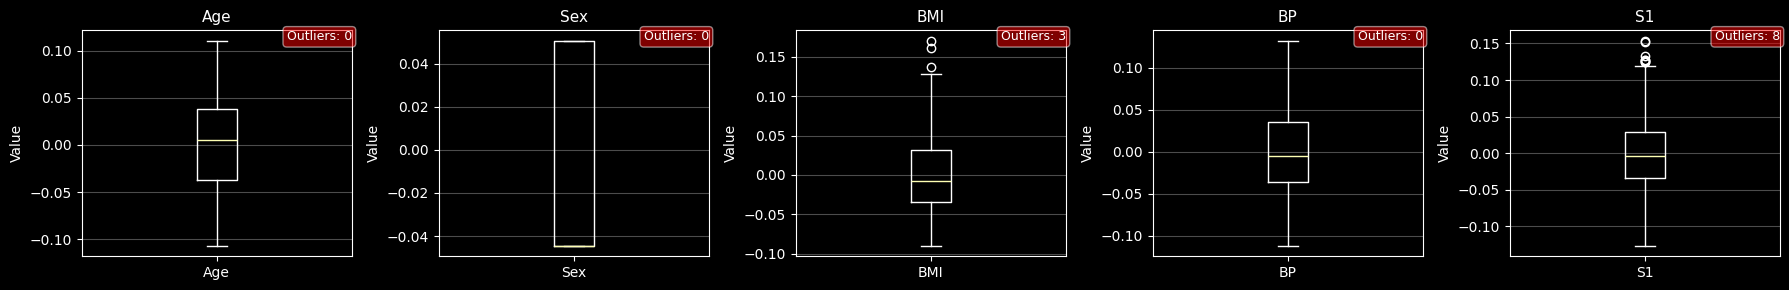

In [ ]:
from matplotlib.patches import bbox_artist
# YOUR TASK: Create box plots for all 5 features
# YOUR CODE HERE
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes = axes.flatten()

for i, col in enumerate(df_diabetes.columns):
    bp = axes[i].boxplot([df_diabetes[col]], tick_labels=[col])
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')


    # Count outliers
    Q1 = df_diabetes[col].quantile(0.25)
    Q3 = df_diabetes[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = ((df_diabetes[col] < lower_bound) | (df_diabetes[col] > upper_bound)).sum()
    axes[i].text(1,1, f'Outliers: {outliers}', transform=axes[i].transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("✅ Exercise 1 passed!")

✅ Exercise 1 passed!


---

# 2. Correlation Analysis

**Correlation coefficient (r):**

- **r = 1:** Perfect positive correlation
- **r = 0:** No correlation
- **r = -1:** Perfect negative correlation

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$


In [ ]:
corr_matrix = df_housing.corr()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [ ]:
# Compute correlation matrix
corr_matrix = df_housing.corr()

print("Correlation with Target (Price):")
corr_matrix['Price'].sort_values(ascending=False)

Correlation with Target (Price):


,Price
Price,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


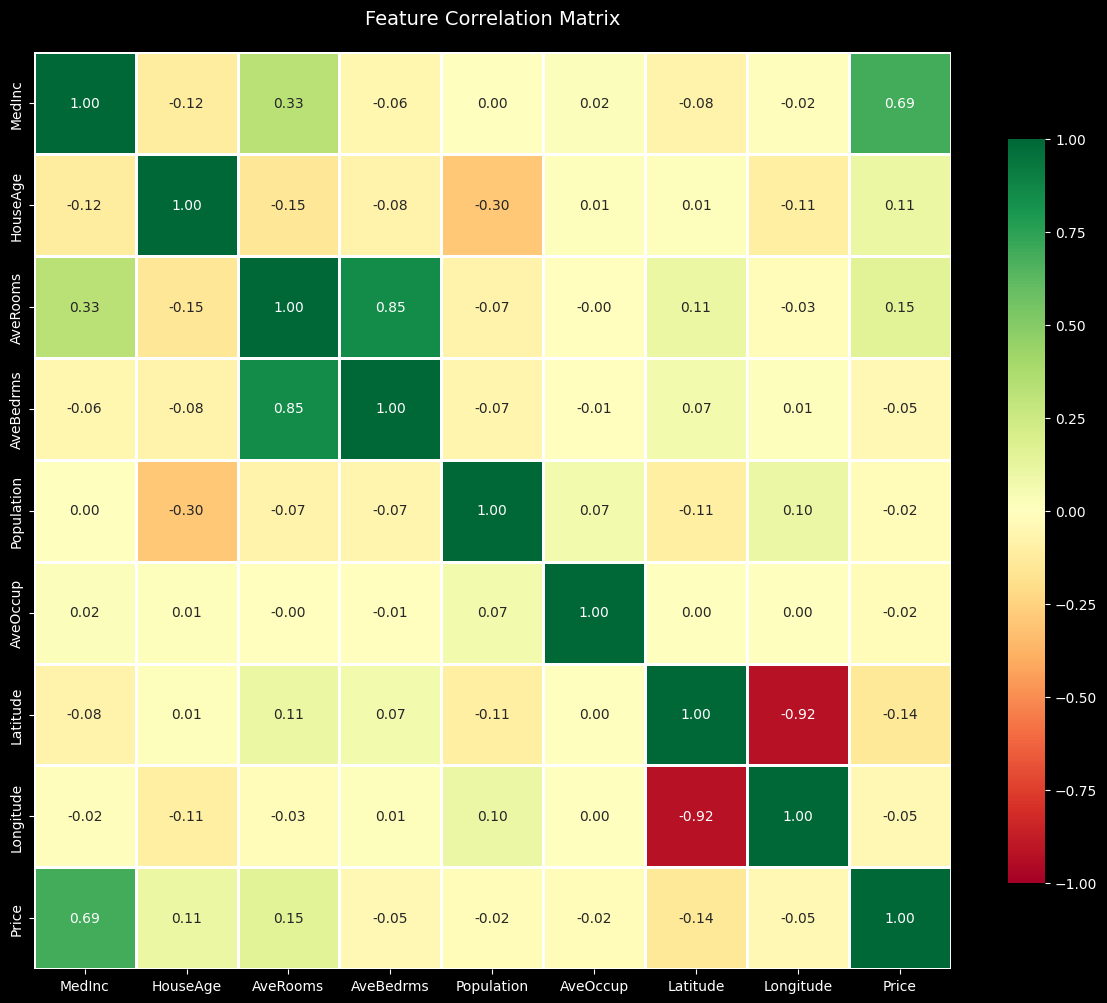

In [ ]:
# Correlation heatmap .. note how the color reflects the value (use the colorbar on the right as the reference)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,  # annot=True - Shows correlation values inside each cell,  cmap='RdYlGn' - Color scheme: Red (negative) → Yellow (neutral) → Green (positive)
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

###### How to Read the Correlation Heatmap
**"How does MedInc correlate with Price?"**
→ **0.69** (strong green)
This means: Higher median income strongly correlates with higher house prices.

**"How does Latitude correlate with Longitude?"**
→ **-0.92** (strong red)
This means: As latitude increases, longitude decreases (makes sense geographically - California's shape).
###### What to Look For
1. **Strong correlations with Price** → Important features
2. **Strong correlations between features** → Multicollinearity (features that are too similar)
3. **Red cells** → Opposite relationships

In [ ]:
target_corr = corr_matrix['Price'].drop('Price').sort_values()
target_corr

,Price
Latitude,-0.144160
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737
HouseAge,0.105623
AveRooms,0.151948
MedInc,0.688075


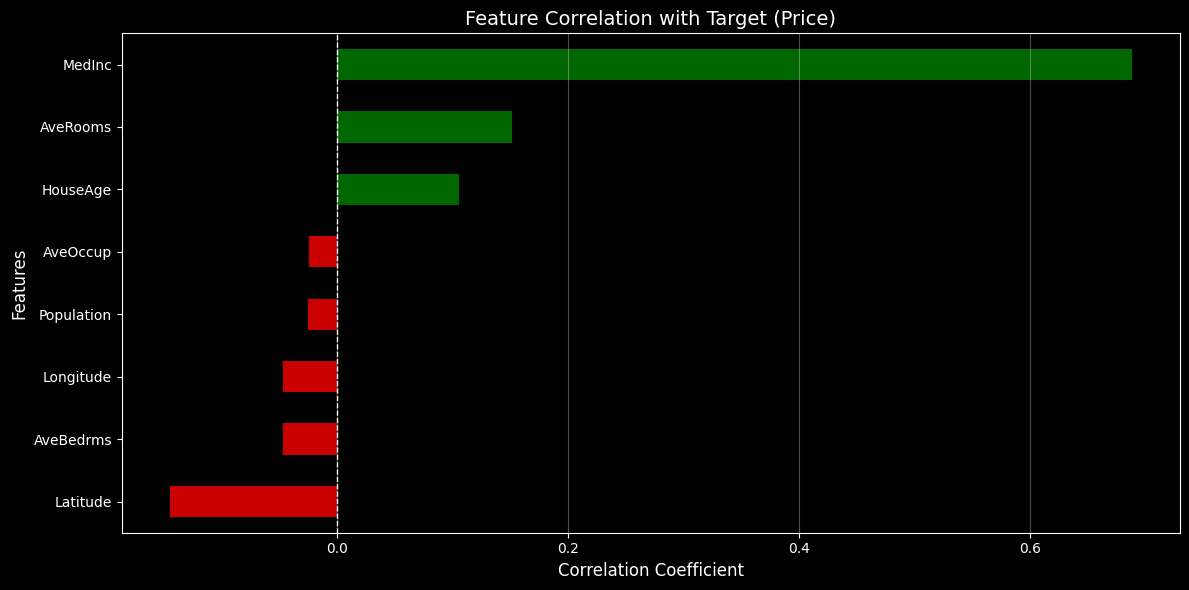

In [ ]:
# Target correlation bar plot, see how we can use this plot to visualise correlation values
fig, ax = plt.subplots(figsize=(12, 6))
target_corr = corr_matrix['Price'].drop('Price').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr]  # to change that to specific color based on direction of correlation
target_corr.plot(kind='barh', color=colors, ax=ax, alpha=0.8) # Horizontal bar chart
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Correlation with Target (Price)', fontsize=14)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Exercise 2: Find Highly Correlated Features

**Task:** Identify all feature pairs with |correlation| > 0.7


In [ ]:
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [ ]:
def find_high_corr_pairs(corr_matrix, threshold):
  high_corr_pairs = []
  for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)): # Iterate through upper triangle of the matrix
      correlation_value = corr_matrix.iloc[i, j]   # Access the specific correlation value between feature i and feature j
      if abs(correlation_value) > threshold:
        high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], correlation_value))
  return np.array(high_corr_pairs)

corr_matrix = df_housing.corr()
threshold = 0.7
high_corr_pairs = find_high_corr_pairs(corr_matrix, threshold)

print(f"\nFound {len(high_corr_pairs)} highly correlated pairs:")
for pair in high_corr_pairs:
    print(f"  {pair[0]} and {pair[1]} (Correlation: {pair[2]:.3f})")


Found 2 highly correlated pairs:
  AveRooms and AveBedrms (Correlation: 0.848)
  Latitude and Longitude (Correlation: -0.925)


In [ ]:
print("✅ Exercise 2 passed!")

✅ Exercise 2 passed!


---

# 3. Multicollinearity Detection

**Multicollinearity:** When features are highly correlated with each other

**Problems it causes:**

1. Unstable coefficient estimates
2. High variance in predictions
3. Difficulty interpreting feature importance

**Detection Methods: we can visually inspect correlations to detect it and we can also use Variance Inflation Factor (VIF)**

$$VIF_i = \frac{1}{1 - R_i^2}$$

Where $R_i^2$ is the R² from regressing feature $i$ on all other features.

**Rule of thumb:**

- VIF < 5: Low multicollinearity
- VIF 5-10: Moderate multicollinearity
- VIF > 10: High multicollinearity (problematic!)

VIF won't be able to tell which feature correlated with which.


In [ ]:
# Compute VIF for each feature
def compute_vif(X):
    """Compute VIF for each feature"""
    vif_data = []
    for i in range(X.shape[1]):
        # Use all other features to predict feature i
        X_i = X[:, i]
        X_others = np.delete(X, i, axis=1)

        # Fit linear regression
        lr = LinearRegression()
        lr.fit(X_others, X_i)

        # Compute R²
        r_squared = lr.score(X_others, X_i)

        # VIF = 1 / (1 - R²)
        vif = 1 / (1 - r_squared) if r_squared < 0.999 else np.inf
        vif_data.append(vif)

    return np.array(vif_data)


X_housing = housing.data
vif_values = compute_vif(X_housing)

print("Feature                VIF")
print("-" * 35)
for name, vif in zip(housing.feature_names, vif_values):
    print(f"{name:15s} {vif:10.2f}")

Feature                VIF
-----------------------------------
MedInc                2.50
HouseAge              1.24
AveRooms              8.34
AveBedrms             6.99
Population            1.14
AveOccup              1.01
Latitude              9.30
Longitude             8.96


### Exercise 3: Compute VIF

**Task:** Compute VIF for the Diabetes dataset features.


In [ ]:
# Load diabetes data
diabetes = load_diabetes()
X_diabetes = diabetes.data[:, :5]  # Use first 5 features
feature_names_diabetes = ['Age', 'Sex', 'BMI', 'BP', 'S1']

print(f"Diabetes features: {feature_names_diabetes}")

Diabetes features: ['Age', 'Sex', 'BMI', 'BP', 'S1']


In [ ]:
# YOUR TASK: Compute VIF for diabetes features
# YOUR CODE HERE
def compute_vif(X):
    """Compute VIF for each feature"""
    vif_data = []
    for i in range(X.shape[1]):
        # Use all other features to predict feature i
        X_i = X[:, i]
        X_others = np.delete(X, i, axis = 1) # Corrected line: pass the index 'i' instead of the array 'X_i'
        lr = LinearRegression()
        lr.fit(X_others, X_i)
        r_squared = lr.score(X_others, X_i)
        vif = 1/(1-r_squared) if r_squared < 0.999 else np.inf
        vif_data.append(vif)
    return np.array(vif_data)
vif_data = compute_vif(X_diabetes)

for name, vif in zip(feature_names_diabetes, vif_data):
    print(f"{name:5s} {vif:10.2f}")


Age         1.19
Sex         1.08
BMI         1.22
BP          1.36
S1          1.14


In [ ]:
print("✅ Exercise 3 passed!")

✅ Exercise 3 passed!


---

# 4. Handling Multicollinearity

Remove highly correlated features


In [ ]:
# Create dataset with SEVERE multicollinearity
np.random.seed(42)
n = 500

# Base feature
x1 = np.random.randn(n)

# Highly correlated features
x2 = x1 + np.random.randn(n) * 0.1  # Almost identical to x1
x3 = 2 * x1 + np.random.randn(n) * 0.1  # Linear combination of x1
x4 = np.random.randn(n)  # Independent feature

# Target depends on x1 and x4
y = 3 * x1 + 2 * x4 + np.random.randn(n) * 0.5

X_multicol = np.column_stack([x1, x2, x3, x4])
feature_names_demo = ['X1', 'X2 (≈X1)', 'X3 (≈2×X1)', 'X4']

# Check correlations
corr_demo = np.corrcoef(X_multicol.T)
print("Correlation Matrix:")
print("        ", "  ".join(f"{name:12s}" for name in feature_names_demo))
for i, name in enumerate(feature_names_demo):
    print(f"{name:8s}", "  ".join(f"{corr_demo[i,j]:12.3f}" for j in range(4)))

Correlation Matrix:
         X1            X2 (≈X1)      X3 (≈2×X1)    X4          
X1              1.000         0.995         0.999         0.064
X2 (≈X1)        0.995         1.000         0.994         0.062
X3 (≈2×X1)        0.999         0.994         1.000         0.063
X4              0.064         0.062         0.063         1.000


In [ ]:
# def remove_multiC(X, f_n, threshold):
#   corr_x = np.corrcoef(X.T)
#   to_remove = set()
#   for i in range(len(f_n)):
#     for j in range(i+1,len(f_n)):
#       corr_value = corr_x[i,j]
#       if abs(corr_value) > threshold and j not in to_remove:
#         to_remove.add(j)
#         print(f"  Removing {f_n[j]} (corr with {f_n[i]}: {corr_value:.3f})")
#   indices=[i for i in range(len(f_n)) if i not in to_remove]
#   X_new = X[:,indices]
#   feature_names_new = [f_n[i] for i in indices]
#   return X_new, feature_names_new, to_remove, indices
# X_new, feature_names_new, to_remove, indices = remove_multiC(X_multicol, feature_names_demo, threshold=0.9)
# print(f"\nReduced from {X_multicol.shape[1]} to {X_new.shape[1]} features")
# print(f"Remaining: {feature_names_new}")
# print(to_remove)
# print(indices)

  Removing X2 (≈X1) (corr with X1: 0.995)
  Removing X3 (≈2×X1) (corr with X1: 0.999)

Reduced from 4 to 2 features
Remaining: ['X1', 'X4']
{1, 2}
[0, 3]


### One way to address this issue is to remove correlated features:


In [ ]:
# Remove features with correlation > 0.9
def remove_correlated_features(X, feature_names, threshold=0.9):
    """Remove features with correlation > threshold"""
    corr = np.corrcoef(X.T)
    to_remove = set()

    for i in range(len(feature_names)):
        for j in range(i+1, len(feature_names)):
            if abs(corr[i, j]) > threshold and j not in to_remove:
                to_remove.add(j)
                print(f"  Removing {feature_names[j]} (corr with {feature_names[i]}: {corr[i,j]:.3f})")

    keep_indices = [i for i in range(len(feature_names)) if i not in to_remove]
    return X[:, keep_indices], [feature_names[i] for i in keep_indices]


X_reduced, names_reduced = remove_correlated_features(X_multicol, feature_names_demo, threshold=0.9)
print(f"\nReduced from {X_multicol.shape[1]} to {X_reduced.shape[1]} features")
print(f"Remaining: {names_reduced}")

  Removing X2 (≈X1) (corr with X1: 0.995)
  Removing X3 (≈2×X1) (corr with X1: 0.999)

Reduced from 4 to 2 features
Remaining: ['X1', 'X4']


---

## Summary

✅ **Data Visualization:**

- Histograms reveal distributions
- Box plots detect outliers
- Scatter matrices show relationships

✅ **Correlation Analysis:**

- Identify feature-target relationships
- Find redundant features

✅ **Multicollinearity Detection:**

- Use correlation matrix
- Compute VIF

✅ **Handling Multicollinearity:**

- Remove correlated features
